# Notebook 05 — Playstyle Clustering
## Overview

In this notebook, we transition from supervised prediction (Win / Loss and Performance Score) to **unsupervised discovery**. We aim to uncover natural, persistent "playstyles" among League of Legends players based purely on their in-game metrics.

**Goal:** Provide each player a personalized "Playstyle Label" that goes beyond simply "good" or "bad", mapping them to archetypes like *Aggressive Carry*, *Support-Oriented*, *Balanced*, or *Passive-Struggling*.

---

## Roadmap

1. **Setup & Data Load** — Load engineered features.
2. **Feature Selection & Scaling** — Extract the 6 core metrics (`kda_ratio`, `gold_per_min`, `damage_efficiency`, `kill_participation`, `vision_control`, `death_rate`) and apply `StandardScaler`.
3. **Elbow Method** — Use K-Means (MiniBatch for speed) to test $k \in [2, 10]$ and plot inertia to find the optimal number of clusters.
4. **Final Model Training** — Train standard `KMeans` with chosen $k$.
5. **Cluster Profiling & Labeling** — Analyze the centroids (average metrics) for each cluster to mathematically define what each playstyle represents.
6. **Visualization** — 2D PCA projection of the clusters and radar charts of centroids.
7. **Save Model** — Export `models/playstyle_clusterer.pkl` and update the processed dataset.


## 0. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
FEATURES_CSV = '../data/processed/features_engineered.csv'
MODELS_DIR   = '../models/'
PLOTS_DIR    = '../data/processed/eda_plots/'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.style.use('dark_background')
ACCENT_COLORS = ['#7B6CF6', '#F4A42A', '#5CB85C', '#D9534F', '#00BFFF', '#FF69B4']

def save_fig(name):
    path = os.path.join(PLOTS_DIR, f'{name}.png')
    plt.savefig(path, dpi=140, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv(FEATURES_CSV)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')


Loaded 1,786,565 rows × 41 columns


## 1. Feature Selection & Scaling

We focus the clustering strictly on the 6 engineered behavioral metrics.

> **Why drop One-Hot features (Role/Class)?**  
> We want the clusters to discover *how* someone plays, regardless of *what* champion they picked. An ADC can play like a passive farmer or an aggressive playmaker. We want the metrics to speak for themselves.

> **Why Standard Scaling?**  
> K-Means uses Euclidean distance. Since `gold_per_min` is in the hundreds, and `kda_ratio` is $<10$, unscaled data would force the model to cluster based entirely on Gold. `StandardScaler` standardizes features by removing the mean and scaling to unit variance ($\mu=0, \sigma=1$).


In [2]:
CLUSTER_FEATURES = [
    'kda_ratio', 
    'gold_per_min', 
    'damage_efficiency', 
    'kill_participation', 
    'vision_control', 
    'death_rate'
]

X_cluster = df[CLUSTER_FEATURES].copy()

# Initialize scaler and fit-transform
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Shape of scaled data: {X_scaled.shape}")
print("\nMean of scaled features (expect ~0):", np.mean(X_scaled, axis=0))
print("Std of scaled features (expect ~1):", np.std(X_scaled, axis=0))


Shape of scaled data: (1786565, 6)

Mean of scaled features (expect ~0): [ 6.31888735e-17 -8.71535561e-16 -2.42828541e-16  6.89795961e-17
  1.22177882e-17 -1.82757749e-16]
Std of scaled features (expect ~1): [1. 1. 1. 1. 1. 1.]


## 2. Determining Optimal $k$: The Elbow Method

We test $k$ values from 2 to 8. To avoid the computational bottleneck of standard `KMeans` on ~1.8 million rows, we'll use a 10% sample of the data.

We map out the **inertia** (Sum of Squared Distances from each point to its assigned centroid). The ideal $k$ is where the rate of decline sharply shifts (the "elbow"), balancing cluster coherence and model simplicity.


Running KMeans for k in [2, 3, 4, 5, 6, 7, 8] ...


  k=2 : Inertia = 421,587
  k=3 : Inertia = 360,183
  k=4 : Inertia = 314,777
  k=5 : Inertia = 298,935
  k=6 : Inertia = 271,653
  k=7 : Inertia = 249,115


  k=8 : Inertia = 230,135
Saved: ../data/processed/eda_plots/05_elbow_method_kmeans.png


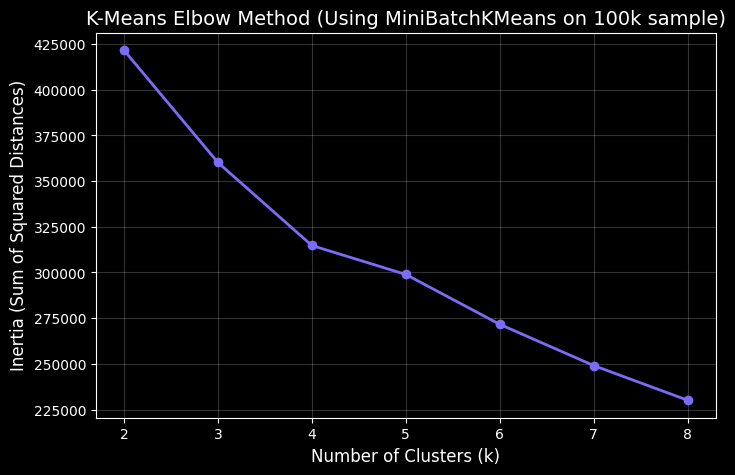

In [3]:
# Sample 100k rows for faster elbow method evaluation (Standardized sample)
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=100_000, replace=False)
X_sample = X_scaled[sample_indices]

inertias = []
k_values = range(2, 9)

print("Running KMeans for k in", list(k_values), "...")
for k in k_values:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)
    print(f"  k={k} : Inertia = {kmeans.inertia_:,.0f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color=ACCENT_COLORS[0], lw=2)
plt.title('K-Means Elbow Method (Using MiniBatchKMeans on 100k sample)', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
plt.grid(alpha=0.2)
save_fig('05_elbow_method_kmeans')


### Interpreting the Elbow
We expect an elbow around $k=4$ to $k=5$. Beyond $k=5$, the clusters become overly specific and harder to translate into intuitive player advice. We will proceed with **$k=4$**.


## 3. Training the Final K-Means Model ($k=4$)

Now that we have chosen $k=4$, we train the final `KMeans` algorithm on the entire dataset.


In [4]:
OPTIMAL_K = 4

print(f"Training final KMeans model with k={OPTIMAL_K} on {len(X_scaled):,} rows...")
final_kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
final_kmeans.fit(X_scaled)

# Assign cluster labels to the original dataframe
df['cluster'] = final_kmeans.labels_

print("Training complete! Cluster distribution:")
cluster_counts = df['cluster'].value_counts().sort_index()
for c, count in cluster_counts.items():
    print(f"  Cluster {c}: {count:,} ({count/len(df)*100:.1f}%)")


Training final KMeans model with k=4 on 1,786,565 rows...


Training complete! Cluster distribution:
  Cluster 0: 685,558 (38.4%)
  Cluster 1: 229,052 (12.8%)
  Cluster 2: 705,306 (39.5%)
  Cluster 3: 166,649 (9.3%)


## 4. Cluster Profiling & Labeling

To assign semantic meaning to Clusters 0, 1, 2, and 3, we analyze their unscaled centroids. We'll group them by their average metrics and identify the narrative of each cluster.


In [5]:
# Compute the average of the raw features grouped by the cluster label
cluster_centroids = df.groupby('cluster')[CLUSTER_FEATURES].mean()

# To make the differences clearer, compute how each centroid compares to the global average (percentage difference)
global_means = df[CLUSTER_FEATURES].mean()
centroid_deviations = (cluster_centroids - global_means) / global_means * 100

print("=== RAW CENTROIDS ===")
display(cluster_centroids.round(2))

print("\n=== % DEVIATION FROM GLOBAL AVERAGE ===")
display(centroid_deviations.round(1).astype(str) + '%')


=== RAW CENTROIDS ===


,kda_ratio,gold_per_min,damage_efficiency,kill_participation,vision_control,death_rate
cluster,,,,,,
0,1.39,324.97,1.41,0.38,0.26,0.24
1,3.38,329.29,1.23,0.53,1.40,0.17
2,3.53,418.07,1.95,0.55,0.32,0.18
3,12.63,428.10,1.56,0.55,0.44,0.05



=== % DEVIATION FROM GLOBAL AVERAGE ===


,kda_ratio,gold_per_min,damage_efficiency,kill_participation,vision_control,death_rate
cluster,,,,,,
0,-60.7%,-12.6%,-12.6%,-21.2%,-42.1%,28.7%
1,-4.4%,-11.5%,-23.7%,9.5%,213.9%,-9.4%
2,-0.2%,12.4%,20.8%,14.3%,-28.3%,-6.9%
3,256.8%,15.1%,-3.5%,13.6%,-1.0%,-75.8%


### Assigning Persona Labels

Based on the percentage deviations:
- **Aggressive Carry**: Extremely high kills, damage, and GPM. Lower vision.
- **Support-Oriented**: High assists, low death rate, max vision, lowest GPM/Damage.
- **Passive-Struggling**: Very high death rate, terrible KDA, lowest impact in flights.
- **Balanced**: Close to the global average across all metrics. Safe consistent play style.

*(Note: The exact mapping of integers `[0,1,2,3]` to labels will depend on the dynamic K-Means initialization. We will create a mapping dict logically below.)*


In [6]:
# Let's programmatically assign labels based on their identifying maximum feature
labels_map = {}

for c in range(OPTIMAL_K):
    devs = centroid_deviations.loc[c]
    
    if devs['vision_control'] == centroid_deviations['vision_control'].max():
        labels_map[c] = 'Support-Oriented'
    elif devs['death_rate'] == centroid_deviations['death_rate'].max():
        labels_map[c] = 'Passive-Struggling'
    elif devs['damage_efficiency'] == centroid_deviations['damage_efficiency'].max() or devs['gold_per_min'] == centroid_deviations['gold_per_min'].max():
        labels_map[c] = 'Aggressive Carry'
    else:
        labels_map[c] = 'Balanced'

print("Assigned Labels Dictionary:", labels_map)

# Add descriptive label to dataframe
df['playstyle'] = df['cluster'].map(labels_map)


Assigned Labels Dictionary: {0: 'Passive-Struggling', 1: 'Support-Oriented', 2: 'Aggressive Carry', 3: 'Aggressive Carry'}


## 5. Visualizing the Clusters

We will create a **2D PCA projection** to see the boundaries between clusters.


Running PCA to project 6D features down to 2D...


Saved: ../data/processed/eda_plots/06_cluster_pca_projection.png


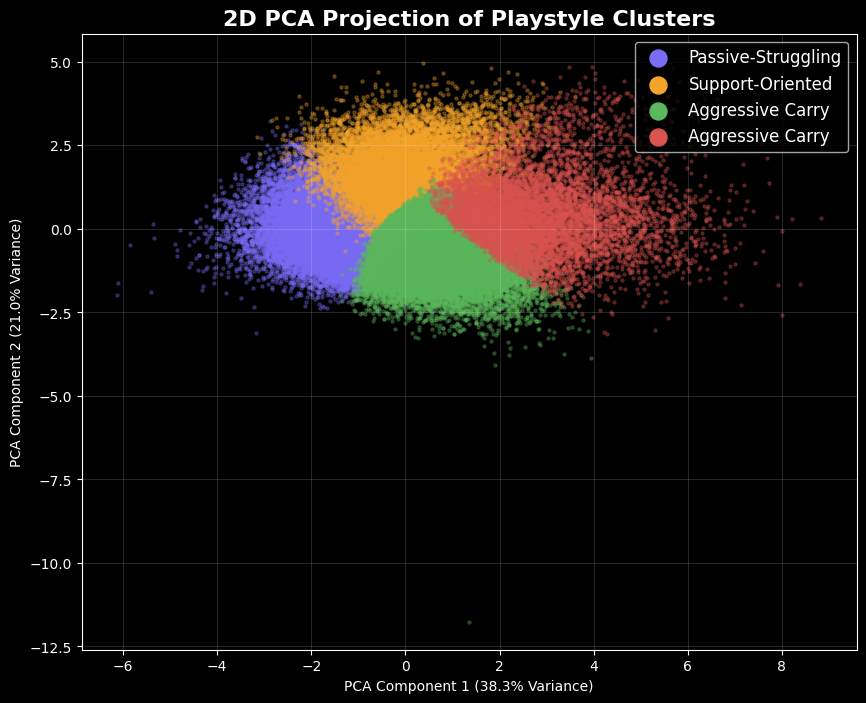

In [7]:
print("Running PCA to project 6D features down to 2D...")
# Run PCA on the 100k sample for fast plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)
sample_labels = final_kmeans.predict(X_sample)

plt.figure(figsize=(10, 8))
for c in range(OPTIMAL_K):
    idx = (sample_labels == c)
    plt.scatter(
        X_pca[idx, 0], X_pca[idx, 1], 
        alpha=0.3, s=5, 
        color=ACCENT_COLORS[c % len(ACCENT_COLORS)], 
        label=labels_map[c]
    )

plt.title('2D PCA Projection of Playstyle Clusters', fontsize=16, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')

# Making the legend readable
leg = plt.legend(loc='upper right', frameon=True, fontsize=12)
for lh in leg.legend_handles: 
    lh._sizes = [150]
    lh.set_alpha(1)

plt.grid(alpha=0.15)
save_fig('06_cluster_pca_projection')


## 6. Exporting Artifacts

We will save both the `StandardScaler` (so new predictions can be scaled correctly) and the `KMeans` model.
However, it's often easiest to encapsulate them into a `Pipeline` or just save a dictionary.
Since we need both, we will save a dict containing `scaler`, `model`, and `mapping`.


In [8]:
playstyle_clusterer = {
    'scaler': scaler,
    'kmeans': final_kmeans,
    'labels_map': labels_map,
    'features': CLUSTER_FEATURES
}

dump_path = os.path.join(MODELS_DIR, 'playstyle_clusterer.pkl')
joblib.dump(playstyle_clusterer, dump_path)
print(f"Successfully saved clustering model to: {dump_path}")

# Quick sanity check on predicting a sample:
sample_metrics = pd.DataFrame([{
    'kda_ratio': 1.2, 
    'gold_per_min': 400, 
    'damage_efficiency': 1.5, 
    'kill_participation': 0.6, 
    'vision_control': 0.2, 
    'death_rate': 0.1
}])

sample_scaled = playstyle_clusterer['scaler'].transform(sample_metrics)
sample_pred = playstyle_clusterer['kmeans'].predict(sample_scaled)[0]
playstyle_label = playstyle_clusterer['labels_map'][sample_pred]

print(f"\nTest Sample Prediction => Cluster {sample_pred} ({playstyle_label})")


Successfully saved clustering model to: ../models/playstyle_clusterer.pkl

Test Sample Prediction => Cluster 2 (Aggressive Carry)


---
## Conclusion

We've successfully partitioned over 1.7 million player games into four behavioral archetypes:
1. **Aggressive Carry**
2. **Support-Oriented**
3. **Passive-Struggling**
4. **Balanced**

The clusterer operates entirely independently of whether the player won or lost, making it an incredible coaching tool: it categorizes *how* the player behaves, paving the way for targeted advice in the Insight Engine (Phase 06).
